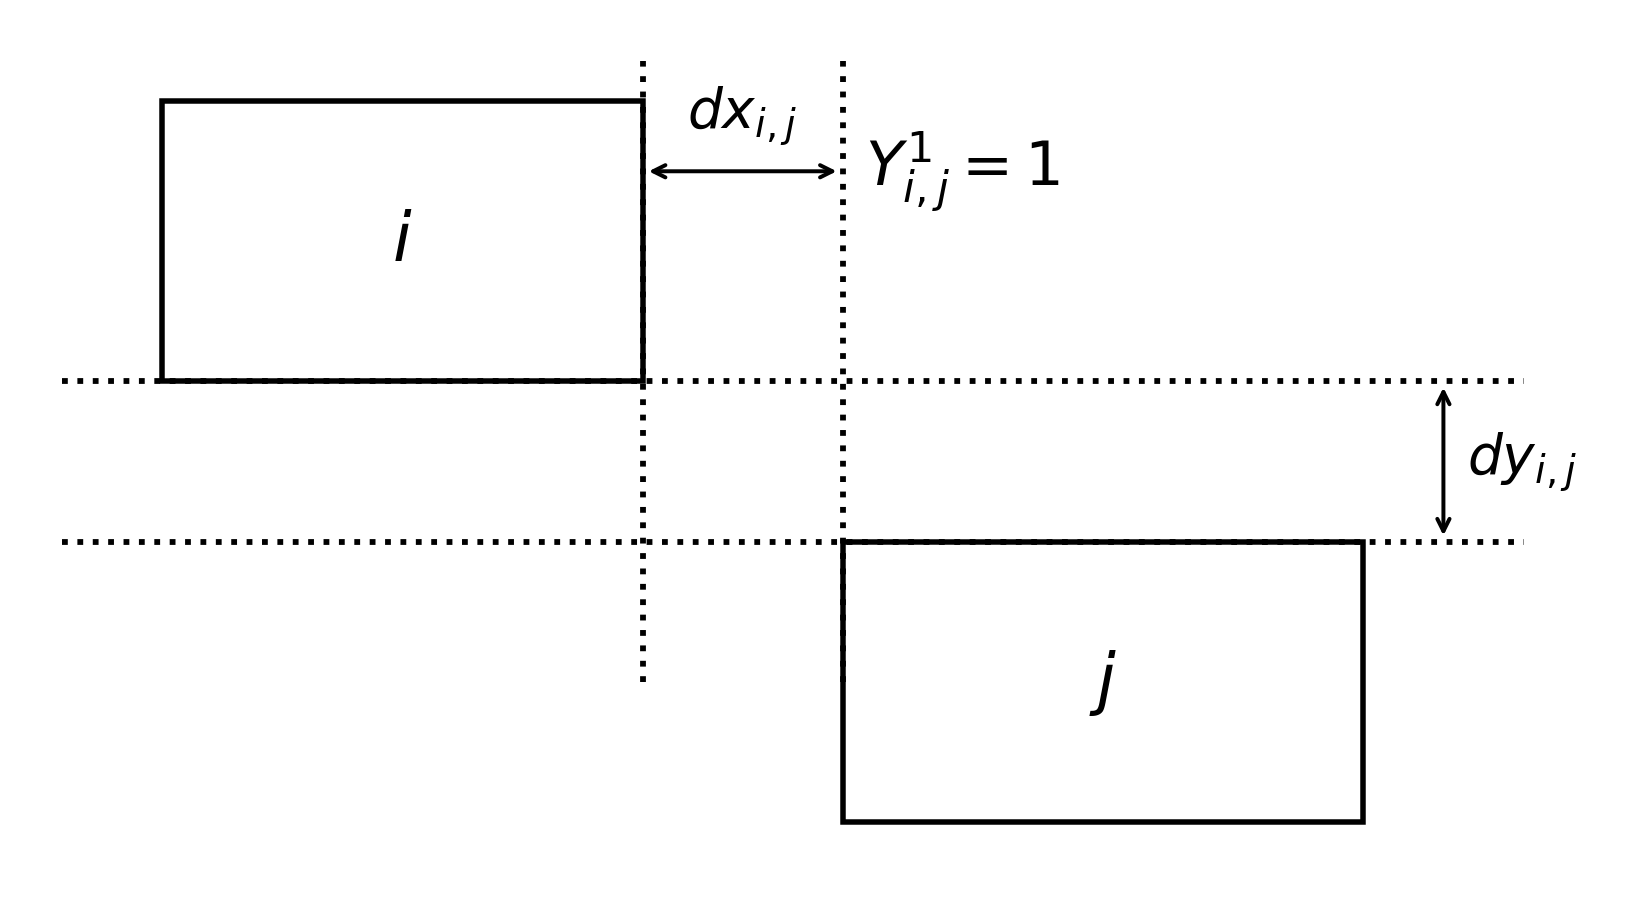

\begin{gather}
\min \; \lambda\,(l_f + w_f) + \sum_{i,j} c_{i,j}( dx_{i,j} + dy_{i,j}) \\
\text{Minimize the weighted facility size plus cost-weighted Manhattan pipe distances ($\lambda = 1$ by default)}\\
\textrm{s.t.} \;l_f \ge y_i + l_i \; \forall  i \in  N \\
\text{Facility length (the vertical $y$ axis) contains every block}\\ 
w_f \ge x_i + w_i \; \forall  i \in  N \\ 
\text{Facility width (the horizontal $x$ axis) contains every block}\\
y_1 = 0, \quad l_f = l_1 \\
\text{The pipe rack (block 1) spans the facility length: pinned at $y=0$ with the facility length fixed to the rack}\\
dx_{i,j} \ge x_i - (x_j + w_j), \quad dx_{i,j} \ge x_j - (x_i + w_i) \; \forall i,j \in N,\, j<i \\
dy_{i,j} \ge y_i - (y_j + l_j), \quad dy_{i,j} \ge y_j - (y_i + l_i) \; \forall i,j \in N,\, j<i \\
\text{Rectilinear edge gaps (0 when blocks overlap on that axis), defined globally, not inside the disjunction}\\
x_i \le UB, \; y_i \le UB \; \forall i \in  N, \quad UB = \sum_{i} \max(l_i,w_i) \\ 
\left[
\begin{array}{c}
Y_{i,j}^1\\
x_i + w_i + d_{i,j} \le x_j\\ 
\text{$i$ is left of $j$}
\end{array}
\right]
\lor
\left[
\begin{array}{c}
Y_{i,j}^2\\
x_j + w_j + d_{i,j} \le x_i\\ 
\text{$i$ is right of $j$}
\end{array}
\right]
\lor
\left[
\begin{array}{c}
Y_{i,j}^3 \\
y_i + l_i + d_{i,j} \le y_j \\ 
\text{$i$ is below $j$}
\end{array}
\right]
\lor
\left[
\begin{array}{c}
Y_{i,j}^4 \\
y_j + l_j + d_{i,j} \le y_i \\ 
\text{$i$ is above $j$}
\end{array}
\right] \\
\text{Non-overlap: exactly one separation per pair, with the minimum clearance $d_{i,j}$ built in}\\
\\
\left[
\begin{array}{c}
Y_{i}^5 \\
l_i = l^0_i \\
w_i = w^0_i\\
\text{Default orientation}
\end{array}
\right]
\lor
\left[
\begin{array}{c}
Y_{i}^6\\
l_i = w^0_i \\
w_i = l^0_i \\
\text{Rotated orientation}
\end{array}
\right] \; \forall i \in N \setminus \{1\} \\ 
\\
l_f,w_f,l_i,w_i,x_i,y_i,dx_{i,j},dy_{i,j} \in \mathbb{R}^1_+ \\
Y_{i,j}^1,Y_{i,j}^2,Y_{i,j}^3,Y_{i,j}^4,Y_{i}^5,Y_{i}^6 \in \text{ \{ True, False \}  } \\
\forall i,j \in N, j <i
\end{gather}

Length is the vertical ($y$) axis and width the horizontal ($x$) axis. Distance is handled by the global $dx,dy$ constraints, so the disjunction decides only non-overlap, never cost. This keeps the objective independent of which spatial relation is chosen, and avoids the costly *continuous* degeneracy that coupling distance into the disjuncts would create. The pipe rack (block 1) spans the facility length and keeps a fixed orientation even when rotation is on, so the rotation disjunction applies to blocks $2 \ldots n$ only. Symmetry breaking (when `sym=1`) anchors block 1 left-of-and-below block 2: $x_1 + w_1/2 \le x_2 + w_2/2$ and $y_1 + l_1/2 \le y_2 + l_2/2$. The footprint weight $\lambda$ defaults to 1. Raise it to favor a smaller facility over cheaper piping.

In [1]:
import random
import pandas as pd
import visuals as vs
from pyomo.environ import (ConcreteModel, NonNegativeReals, Objective, Param,
                           Set, SolverFactory, TransformationFactory, Var, value, RangeSet)
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.patheffects as pe


def create_model(n, w_0, l_0, c_0, d_0, rotate=0, sym=0, footprint_weight=1.0):

    ## Model
    m = ConcreteModel()

    ## Sets
    m.n = Set(ordered=True, initialize=RangeSet(1, n))
    def rec_pairs_filter(m, i, j):
        return i > j
    m.p = Set(initialize=m.n * m.n, dimen=2, filter=rec_pairs_filter)

    ## Parameters
    # Default-orientation width and length of each block
    m.w0 = Param(m.n, initialize=w_0)
    m.l0 = Param(m.n, initialize=l_0)
    # Pipe cost per pair (star topology: each block pipes to the rack, block 1)
    m.c = Param(m.p, initialize=c_0)
    # Minimum separation distance per pair
    m.d = Param(m.p, initialize=d_0)
    # Conservative upper bound on coordinates
    m.UB = Param(initialize=sum(max([m.l0[i], m.w0[i]]) for i in m.n))

    ## Variables
    # Lower-left corner: x is the horizontal (width) axis, y the vertical (length) axis
    m.x = Var(m.n, bounds=(0, m.UB))
    m.y = Var(m.n, bounds=(0, m.UB))
    # Rectilinear edge gaps between each pair (horizontal dx, vertical dy)
    m.dx = Var(m.p, bounds=(0, m.UB))
    m.dy = Var(m.p, bounds=(0, m.UB))
    # Block length (vertical extent) and width (horizontal extent)
    m.l = Var(m.n, bounds=(0, m.UB))
    m.w = Var(m.n, bounds=(0, m.UB))
    # Facility length (vertical) and width (horizontal)
    m.l_f = Var(within=NonNegativeReals)
    m.w_f = Var(within=NonNegativeReals)

    ## Constraints
    # Facility bounding box: length is the vertical (y) axis, width the horizontal (x)
    @m.Constraint(m.n)
    def facility_length(m, i):
        return m.l_f >= m.y[i] + m.l[i]
    @m.Constraint(m.n)
    def facility_width(m, i):
        return m.w_f >= m.x[i] + m.w[i]

    # Pipe rack (block 1) spans the facility length: pinned at y=0 with the
    # facility length fixed to the rack. Only the facility width is minimized.
    @m.Constraint()
    def rack_at_origin(m):
        return m.y[1] == 0
    @m.Constraint()
    def facility_len_eq_rack(m):
        return m.l_f == m.l[1]

    # Rectilinear edge gaps, defined globally so the objective never depends on
    # which spatial relation the disjunction picks. Each is minimized, so it
    # settles to the true clearance (0 if the blocks overlap on that axis).
    @m.Constraint(m.p)
    def dx_lb_a(m, i, j):
        return m.dx[i,j] >= m.x[i] - (m.x[j] + m.w[j])
    @m.Constraint(m.p)
    def dx_lb_b(m, i, j):
        return m.dx[i,j] >= m.x[j] - (m.x[i] + m.w[i])
    @m.Constraint(m.p)
    def dy_lb_a(m, i, j):
        return m.dy[i,j] >= m.y[i] - (m.y[j] + m.l[j])
    @m.Constraint(m.p)
    def dy_lb_b(m, i, j):
        return m.dy[i,j] >= m.y[j] - (m.y[i] + m.l[i])

    # Symmetry breaking: anchor block 1 left-of-and-below block 2's center.
    if sym == 1:
        @m.Constraint()
        def sym_1(m):
            return m.x[1] + m.w[1]/2 <= m.x[2] + m.w[2]/2
        @m.Constraint()
        def sym_2(m):
            return m.y[1] + m.l[1]/2 <= m.y[2] + m.l[2]/2

    ## Objective: weighted facility size + cost-weighted Manhattan piping.
    ## footprint_weight (default 1) trades facility size against piping cost.
    m.obj = Objective(expr=footprint_weight * (m.l_f + m.w_f)
                      + sum(m.c[i,j] * (m.dx[i,j] + m.dy[i,j]) for i,j in m.p))

    # Non-overlap: exactly one of four separations per pair, each a single
    # inequality with the minimum clearance d baked in.
    @m.Disjunction(m.p)
    def no_overlap(m, i, j):
        return [
            [m.x[i] + m.w[i] + m.d[i,j] <= m.x[j]],   # i left of j
            [m.x[j] + m.w[j] + m.d[i,j] <= m.x[i]],   # i right of j
            [m.y[i] + m.l[i] + m.d[i,j] <= m.y[j]],   # i below j
            [m.y[j] + m.l[j] + m.d[i,j] <= m.y[i]],   # i above j
            ]

    # Rotation (optional): a 2-way orientation disjunction per block, except the
    # rack (block 1), which keeps its orientation even when rotation is on.
    if rotate:
        rot_blocks = [i for i in m.n if i != 1]
        @m.Disjunction(rot_blocks)
        def rotation(m, i):
            return [
                [m.l[i] == m.l0[i], m.w[i] == m.w0[i]],   # default orientation
                [m.l[i] == m.w0[i], m.w[i] == m.l0[i]],   # 90 degrees rotated
                ]
        @m.Constraint()
        def fix_rack_l(m):
            return m.l[1] == m.l0[1]
        @m.Constraint()
        def fix_rack_w(m):
            return m.w[1] == m.w0[1]
    else:
        @m.Constraint(m.n)
        def fix_l(m, i):
            return m.l[i] == m.l0[i]
        @m.Constraint(m.n)
        def fix_w(m, i):
            return m.w[i] == m.w0[i]
    return m

In [2]:
# Default instance: the pipe rack (block 1) plus 14 objects. The rack is the
# longest block (length 9, width 1) and spans the facility.
num = 15

# Length (vertical extent) and width (horizontal extent) of each block
l_0 = {1: 9, 2: 1, 3: 2, 4: 2, 5: 2, 6: 2, 7: 2, 8: 3,
       9: 3, 10: 1, 11: 1, 12: 3, 13: 3, 14: 3, 15: 1}
w_0 = {1: 1, 2: 3, 3: 1, 4: 2, 5: 1, 6: 1, 7: 3, 8: 2,
       9: 1, 10: 2, 11: 1, 12: 1, 13: 1, 14: 1, 15: 2}

# Star topology: every block pipes to the rack (block 1) only, so cost(i, 1) > 0
# for i >= 2 and every other pair is 0.
rack_cost = {2: 1, 3: 2, 4: 3, 5: 1, 6: 2, 7: 1, 8: 2,
             9: 3, 10: 1, 11: 3, 12: 2, 13: 2, 14: 3, 15: 2}
c_0 = {(i, j): (rack_cost[i] if j == 1 else 0)
       for i in range(1, num + 1) for j in range(1, num + 1) if i > j}

# Minimum separation distance for every pair
d_0 = {(i, j): 1 for i in range(1, num + 1) for j in range(1, num + 1) if i > j}

In [3]:
m = create_model(num, w_0, l_0, c_0, d_0, rotate=0, sym=1)
TransformationFactory('gdp.bigm').apply_to(m)

# HiGHS is the open-source MILP solver (pip install highspy). The native appsi
# interface respects the time limit and still loads a timed-out incumbent. On
# this instance HiGHS may hit the limit before proving optimality.
from pyomo.contrib.appsi.solvers import Highs

opt = Highs()
opt.config.time_limit = 60
opt.config.load_solution = False
opt.config.stream_solver = True
res = opt.solve(m)
if res.best_feasible_objective is not None:
    res.solution_loader.load_vars()

print("termination:", res.termination_condition)
print("objective:  ", res.best_feasible_objective)

Running HiGHS 1.14.0 (git hash: 7df0786): Copyright (c) 2026 under MIT licence terms


MIP has 1009 rows; 692 cols; 3911 nonzeros; 420 integer variables (420 binary)
Coefficient ranges:
  Matrix  [5e-01, 9e+01]
  Cost    [1e+00, 3e+00]
  Bound   [1e+00, 4e+01]
  RHS     [1e+00, 9e+01]
Presolving model
919 rows, 450 cols, 2454 nonzeros 0s
519 rows, 422 cols, 1632 nonzeros 0s
519 rows, 422 cols, 1632 nonzeros 0s
Presolve reductions: rows 519(-490); columns 422(-270); nonzeros 1632(-2279) 

Solving MIP model with:
   519 rows
   422 cols (378 binary, 0 integer, 0 implied int., 44 continuous, 0 domain fixed)
   1632 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u => Trivial upper; z => Trivial zero

        Nodes      |    B&B Tree     |            Objective Bounds             

 F       0       0         0   0.00%   42.32143892     345               87.73%     9273    438      0     10900     1.4s

0.3% inactive integer columns, restarting
Model after restart has 517 rows, 421 cols (377 bin., 0 int., 0 impl., 44 cont., 0 dom.fix.), and 1626 nonzeros

         0       0         0   0.00%   42.32143892     345               87.73%      157      0      0     10900     1.4s
         0       0         0   0.00%   42.32143892     345               87.73%      157     85      0     11138     1.5s


 L       0       0         0   0.00%   42.35503844     218               80.57%     6839    378      0     12844     2.4s

Symmetry detection completed in 0.0s
Found 3 generator(s)

 T      53       1         5   0.00%   42.35503844     213               80.12%     6851    158     27     19383     2.4s
 T      55       1         6   0.00%   42.35503844     203               79.14%     6851    158     27     19396     2.4s
 T      56       1         7   0.00%   42.35503844     199               78.72%     6857    158     46     19397     2.4s
 T      57       1         8   0.00%   42.35503844     198               78.61%     6861    158     59     19423     2.5s
 T      61       1         9   0.00%   42.35503844     196               78.39%     6864    158     72     19461     2.5s
 B      66       1        10   0.00%   42.35503844     186               77.23%     6864    158     72     19503     2.5s
 B      67      30        10   0.00%   42.35503844     143               70.38%     76

 T     115      36        15   0.00%   42.35503844     137               69.08%     7679    180    121     20587     2.7s
 B     137      34        22   0.00%   42.35503844     132               67.91%     7701    180    147     20885     2.7s
 B     152      36        28   0.00%   42.35503844     131               67.67%     7714    180    170     21051     2.8s
 T     154      31        29   0.00%   42.35503844     128               66.91%     7716    180    173     21058     2.8s
 T     163      30        33   0.00%   42.35503844     123               65.57%     7724    180    184     21131     2.8s


...

     11822     710      1498   0.07%   42.4            85                50.12%     8359    113   5470    346847    54.5s

Restarting search from the root node
Model after restart has 517 rows, 421 cols (377 bin., 0 int., 0 impl., 44 cont., 0 dom.fix.), and 1626 nonzeros

     11886       0         0   0.00%   42.4            85                50.12%      113      0      0    347723    54.5s

        Nodes      |    B&B Tree     |            Objective Bounds              |  Dynamic Constraints |       Work      
Src  Proc. InQueue |  Leaves   Expl. | BestBound       BestSol              Gap |   Cuts   InLp Confl. | LpIters     Time

     11886       0         0   0.00%   42.4            85                50.12%      113     23      0    347769    54.5s



Symmetry detection completed in 0.0s
Found 3 generator(s)



     16156     625      1684   0.24%   43              85                49.41%     8904    235   5913    409947    59.6s


     16543     701      1843   0.24%   43.25510659     85                49.11%     9272    152   6491    415068    60.0s

Solving report
  Status            Time limit reached
  Primal bound      85
  Dual bound        43.2551065913
  Gap               49.11% (tolerance: 0.01%)
  P-D integral      30.862165902
  Solution status   feasible
                    85 (objective)
                    0 (bound viol.)
                    1.56541446472e-13 (int. viol.)
                    0 (row viol.)
  Timing            60.00
  Max sub-MIP depth 7
  Nodes             16543
  Repair LPs        0
  LP iterations     415068
                    36318 (strong br.)
                    40887 (separation)
                    131040 (heuristics)


termination: TerminationCondition.maxTimeLimit
objective:   84.99999999998886


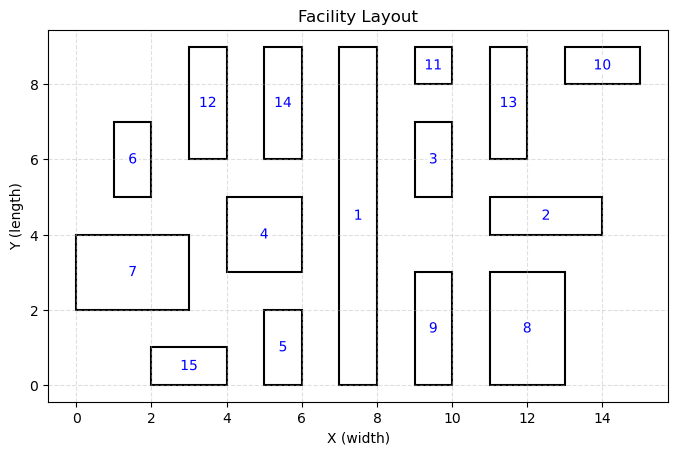

,Rectangle,X (Lower Left),Y (Lower Left),Width (X),Length (Y)
0,1,7,0,1,9
1,2,11,4,3,1
2,3,9,5,1,2
3,4,4,3,2,2
4,5,5,0,1,2
5,6,1,5,1,2
6,7,0,2,3,2
7,8,11,0,2,3
8,9,9,0,1,3
9,10,13,8,2,1


In [4]:
vs.plot_rect_layout(m, title="Facility Layout")
vs.rect_table(m,decimals = 0)

In [5]:
print(c_0)

{(2, 1): 1, (3, 1): 2, (3, 2): 0, (4, 1): 3, (4, 2): 0, (4, 3): 0, (5, 1): 1, (5, 2): 0, (5, 3): 0, (5, 4): 0, (6, 1): 2, (6, 2): 0, (6, 3): 0, (6, 4): 0, (6, 5): 0, (7, 1): 1, (7, 2): 0, (7, 3): 0, (7, 4): 0, (7, 5): 0, (7, 6): 0, (8, 1): 2, (8, 2): 0, (8, 3): 0, (8, 4): 0, (8, 5): 0, (8, 6): 0, (8, 7): 0, (9, 1): 3, (9, 2): 0, (9, 3): 0, (9, 4): 0, (9, 5): 0, (9, 6): 0, (9, 7): 0, (9, 8): 0, (10, 1): 1, (10, 2): 0, (10, 3): 0, (10, 4): 0, (10, 5): 0, (10, 6): 0, (10, 7): 0, (10, 8): 0, (10, 9): 0, (11, 1): 3, (11, 2): 0, (11, 3): 0, (11, 4): 0, (11, 5): 0, (11, 6): 0, (11, 7): 0, (11, 8): 0, (11, 9): 0, (11, 10): 0, (12, 1): 2, (12, 2): 0, (12, 3): 0, (12, 4): 0, (12, 5): 0, (12, 6): 0, (12, 7): 0, (12, 8): 0, (12, 9): 0, (12, 10): 0, (12, 11): 0, (13, 1): 2, (13, 2): 0, (13, 3): 0, (13, 4): 0, (13, 5): 0, (13, 6): 0, (13, 7): 0, (13, 8): 0, (13, 9): 0, (13, 10): 0, (13, 11): 0, (13, 12): 0, (14, 1): 3, (14, 2): 0, (14, 3): 0, (14, 4): 0, (14, 5): 0, (14, 6): 0, (14, 7): 0, (14, 8): 